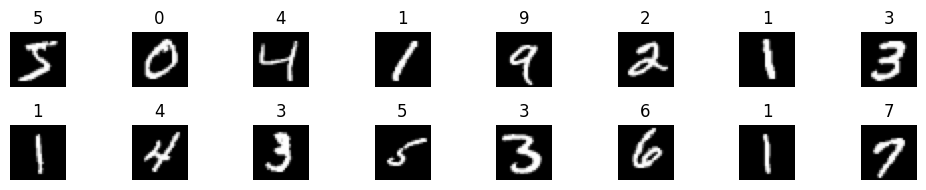

In [1]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor

train = torchvision.datasets.MNIST(root="./data",transform=ToTensor(),train=True,download=True)
test = torchvision.datasets.MNIST(root="./data",transform=ToTensor(),train=False,download=True)

import matplotlib.pyplot as plt

f,ax = plt.subplots(2,8,figsize=(10, 2))

for i,ax in enumerate(ax.flat):
    img,label = train[i]
    ax.imshow(img.squeeze(),cmap="grey")
    ax.axis('off')
    ax.set_title(label)
plt.tight_layout()

class mnistNET(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,10,5),
            nn.MaxPool2d(2,2),
            nn.ReLU(),
            nn.Conv2d(10,20,5),
            nn.Dropout2d(0.3),
            nn.MaxPool2d(2,2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(320,70),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(70,10),
        )
    def forward(self,x):
        return self.net(x)


loaders = {
    "train": DataLoader(dataset=train,batch_size=32,shuffle=True),
    "test": DataLoader(dataset=test,batch_size=32,shuffle=False),
}


In [2]:

from torch.optim import Adam

model = mnistNET().cuda()
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(),lr=1e-4,weight_decay=1e-4)
epochs = 20

# for training 
running= 0
for epoch in range(epochs):
    model.train()
    running = 0
    batch_len = len(loaders["train"])
    for i, (img , label) in enumerate(loaders["train"]):
        img, label = img.cuda(),label.cuda()
        optimizer.zero_grad()
        out = model(img)
        loss = loss_fn(out,label)
        running += loss.item()
        loss.backward()
        optimizer.step()
        
    print(
            f"progress [{epoch+1}/{epochs}] "
            f"Loss: {running / batch_len:.4f}"
        )

progress [1/20] Loss: 0.8766
progress [2/20] Loss: 0.3308
progress [3/20] Loss: 0.2430
progress [4/20] Loss: 0.1993
progress [5/20] Loss: 0.1722
progress [6/20] Loss: 0.1552
progress [7/20] Loss: 0.1409
progress [8/20] Loss: 0.1271
progress [9/20] Loss: 0.1218
progress [10/20] Loss: 0.1143
progress [11/20] Loss: 0.1081
progress [12/20] Loss: 0.1047
progress [13/20] Loss: 0.1014
progress [14/20] Loss: 0.0959
progress [15/20] Loss: 0.0938
progress [16/20] Loss: 0.0896
progress [17/20] Loss: 0.0888
progress [18/20] Loss: 0.0875
progress [19/20] Loss: 0.0818
progress [20/20] Loss: 0.0788


In [3]:

model.eval()

test_loss = 0
correct = 0
total = 0
preds = []

with torch.no_grad():
    for img, label in loaders["test"]:
        img = img.cuda()
        label = label.cuda()

        out = model(img)

        loss = loss_fn(out, label)
        test_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        # print(predicted)
        preds.append(preds.extend(predicted.cpu().tolist()))

        correct += (predicted == label).sum().item()
        total += label.size(0)
    
print(f"Test Loss: {test_loss / len(loaders['test']):.4f}")
print(f"Accuracy: {100 * correct / total:.2f}%")

Test Loss: 0.0412
Accuracy: 98.66%


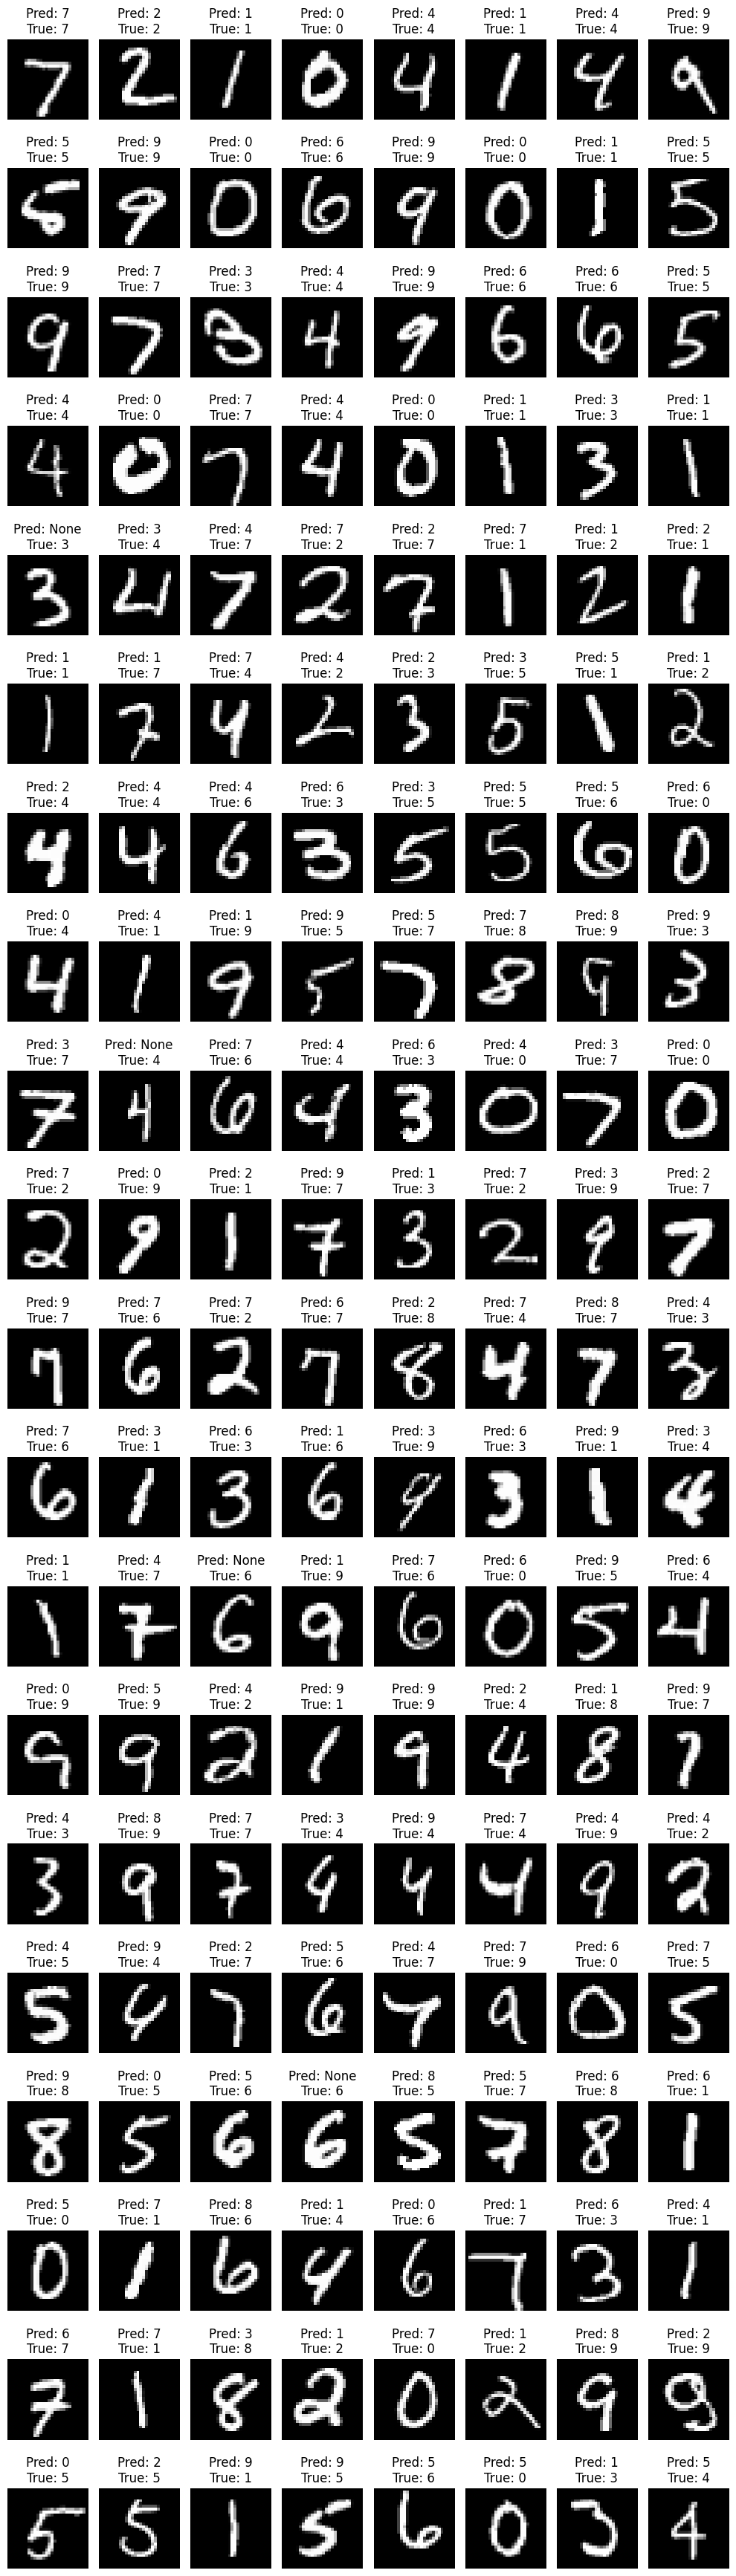

In [4]:
f,ax = plt.subplots(20,8,figsize=(10, 35))

for i,ax in enumerate(ax.flat):
    img,label = test[i]
    ax.imshow(img.squeeze(),cmap="gray")
    ax.axis('off')
    ax.set_title(f"Pred: {preds[i]}\nTrue: {label}")
plt.tight_layout()